# House Price Prediction (Regression)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project predicts house sale prices using the Ames Housing dataset. It includes comprehensive data cleaning, feature engineering, and regression models (Linear Regression, Random Forest, XGBoost). Evaluation uses MAE, RMSE, and R². The notebook demonstrates a complete regression pipeline with 10 visualisations.

## Dataset
- **Source:** Kaggle – House Prices (Ames, Iowa)
- **Rows:** 1,460 training examples
- **Features:** 80 (including numeric and categorical)

## Key Steps
1. Load and inspect data
2. Handle missing values
3. Feature engineering (total area, age, etc.)
4. Encode categorical variables
5. Train and compare models
6. Evaluate and interpret

## Requirements
- pandas, matplotlib, seaborn, scikit-learn, xgboost, shap

---

**© 2026 Ibrahim – House price prediction.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [4]:
# Download from Kaggle (using raw GitHub mirror – may need manual upload)
data = "/content/House Prices.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (21613, 21)


,ID,Date,Price,Bedrooms,Bathrooms,Sqft_living,Sqft_lot,Floors,Waterfront,View,...,Grade,Sqft_above,Sqft_basement,Yr_built,Yr_renovated,zipcode,Lat,Long,Sqft_living15,Sqft_lot15
0,1,20140916T000000,280000.0,6,3.0,2400,9373,2.0,0,0,...,7,2400,0,1991,0,98002,47.3262,-122.214,2060,7316
1,2,20150422T000000,300000.0,6,3.0,2400,9373,2.0,0,0,...,7,2400,0,1991,0,98002,47.3262,-122.214,2060,7316


### Data Overview & Target Distribution

Target variable: Price
Mean: $540,182
Median: $450,000


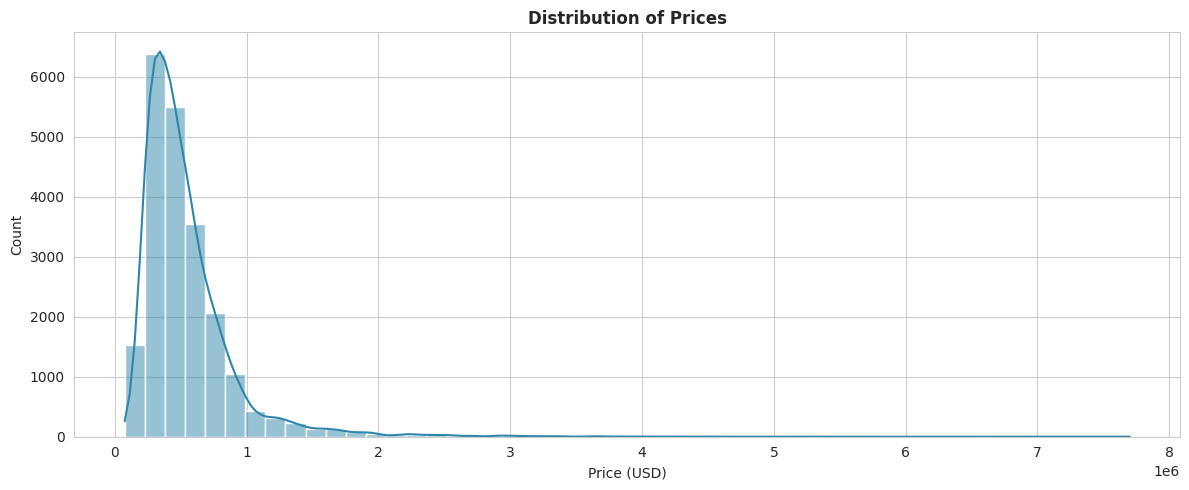

In [6]:
print("Target variable: Price")
print(f"Mean: ${df['Price'].mean():,.0f}")
print(f"Median: ${df['Price'].median():,.0f}")

plt.figure(figsize=(12, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='#2E86AB')
plt.xlabel('Price (USD)')
plt.title('Distribution of Prices', fontweight='bold')
plt.tight_layout()
plt.show()

### SalePrice Distribution (log transform)

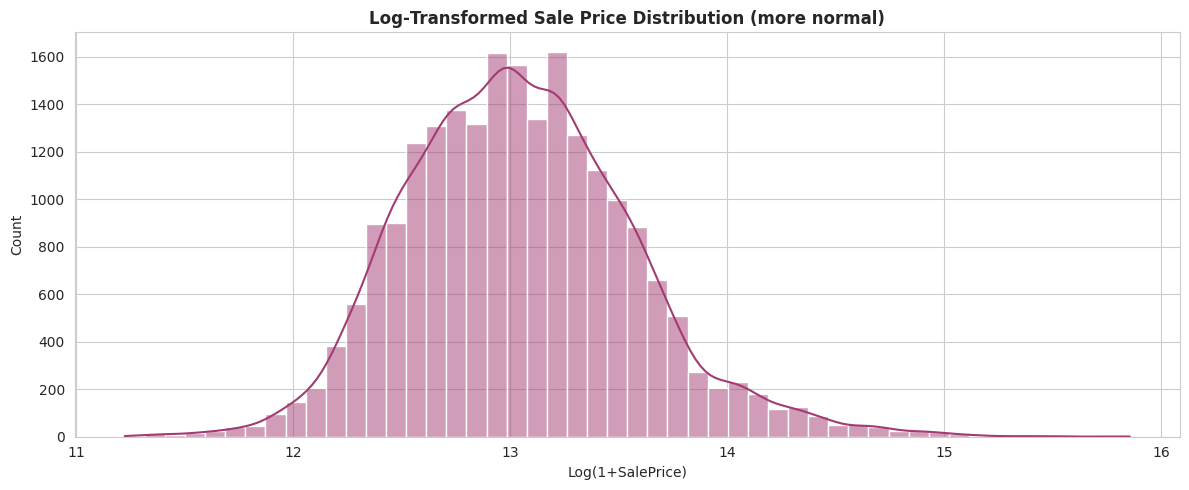

In [8]:
plt.figure(figsize=(12, 5))
sns.histplot(np.log1p(df['Price']), bins=50, kde=True, color='#A23B72')
plt.xlabel('Log(1+SalePrice)')
plt.title('Log‑Transformed Sale Price Distribution (more normal)', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap (Top 15 features with SalePrice)

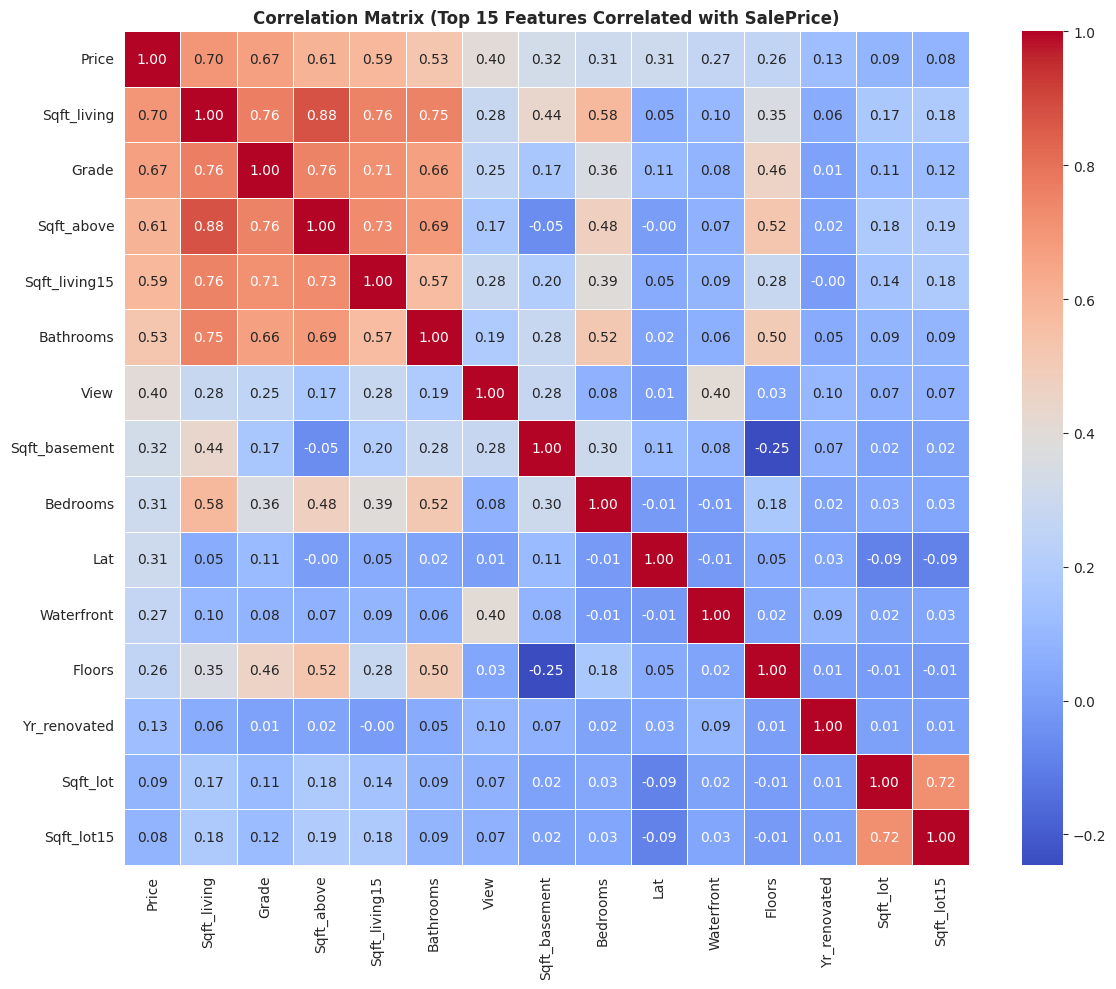

In [9]:
# Compute correlation with SalePrice
corr = df.corr(numeric_only=True)['Price'].abs().sort_values(ascending=False)
top_features = corr.head(15).index.tolist()
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Top 15 Features Correlated with SalePrice)', fontweight='bold')
plt.tight_layout()
plt.show()

### GrLivArea vs SalePrice (Scatter)

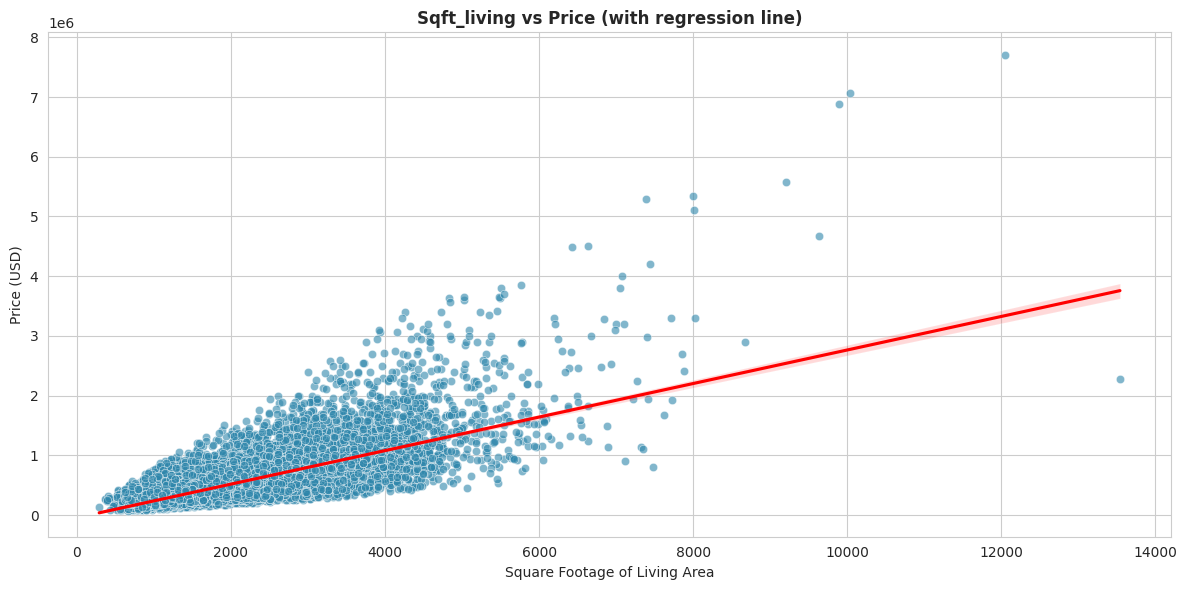

In [11]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Sqft_living', y='Price', alpha=0.6, color='#2E86AB')
sns.regplot(data=df, x='Sqft_living', y='Price', scatter=False, color='red')
plt.xlabel('Square Footage of Living Area')
plt.ylabel('Price (USD)')
plt.title('Sqft_living vs Price (with regression line)', fontweight='bold')
plt.tight_layout()
plt.show()

### OverallQual vs SalePrice (Box Plot)

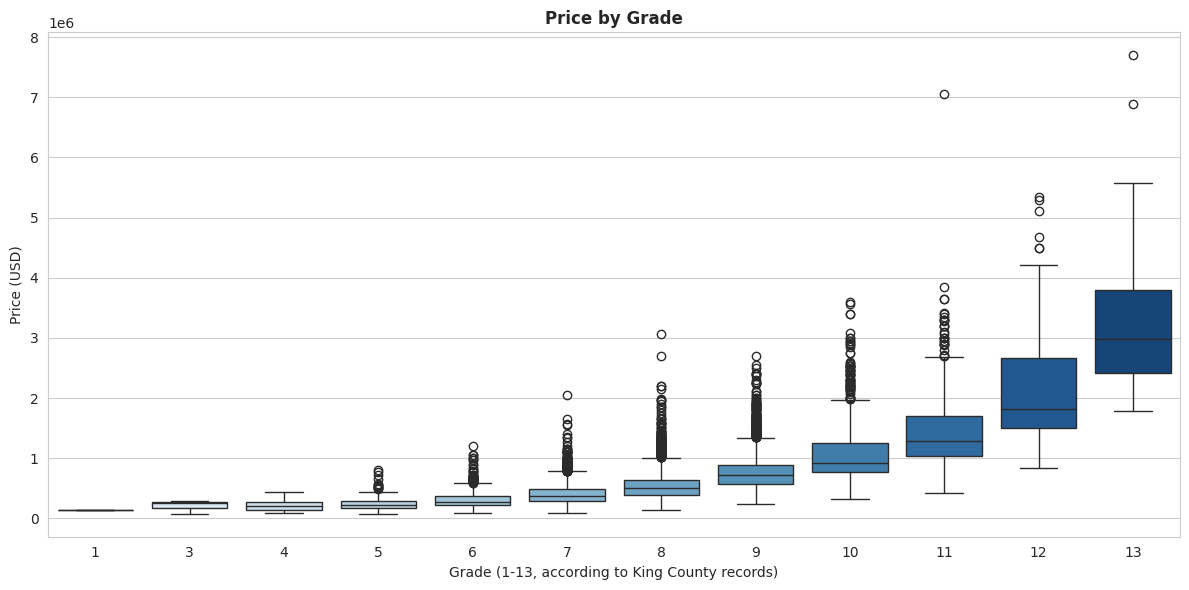

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Grade', y='Price', palette='Blues')
plt.xlabel('Grade (1-13, according to King County records)')
plt.ylabel('Price (USD)')
plt.title('Price by Grade', fontweight='bold')
plt.tight_layout()
plt.show()

### YearBuilt vs SalePrice (Scatter)

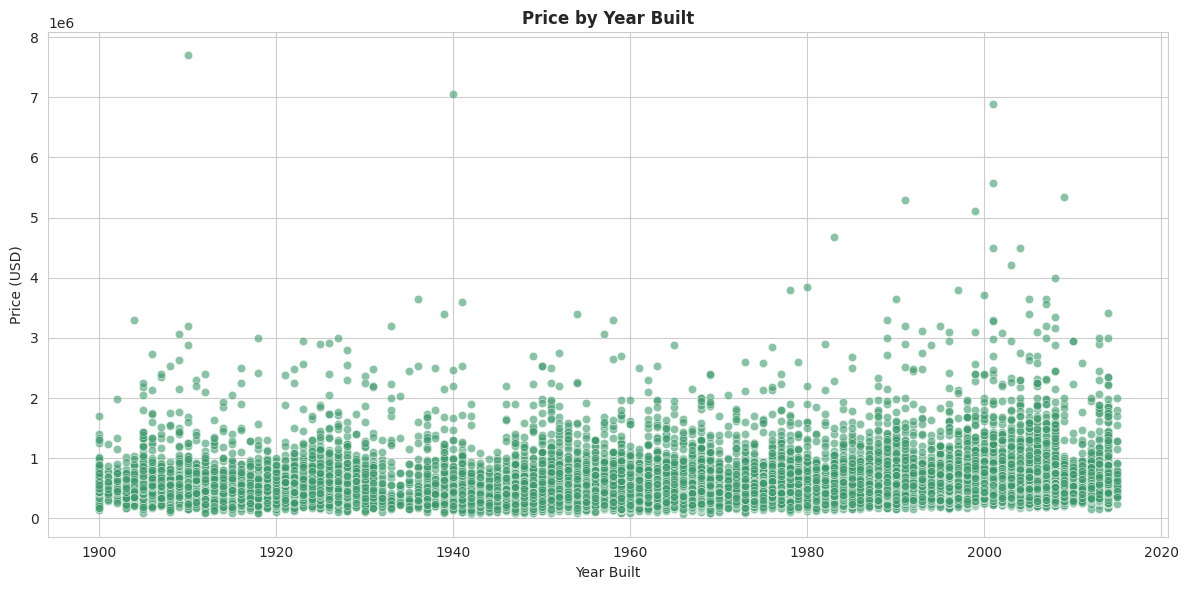

In [16]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Yr_built', y='Price', alpha=0.6, color='#3C9A6A')
plt.xlabel('Year Built')
plt.ylabel('Price (USD)')
plt.title('Price by Year Built', fontweight='bold')
plt.tight_layout()
plt.show()

### Handle Missing Values

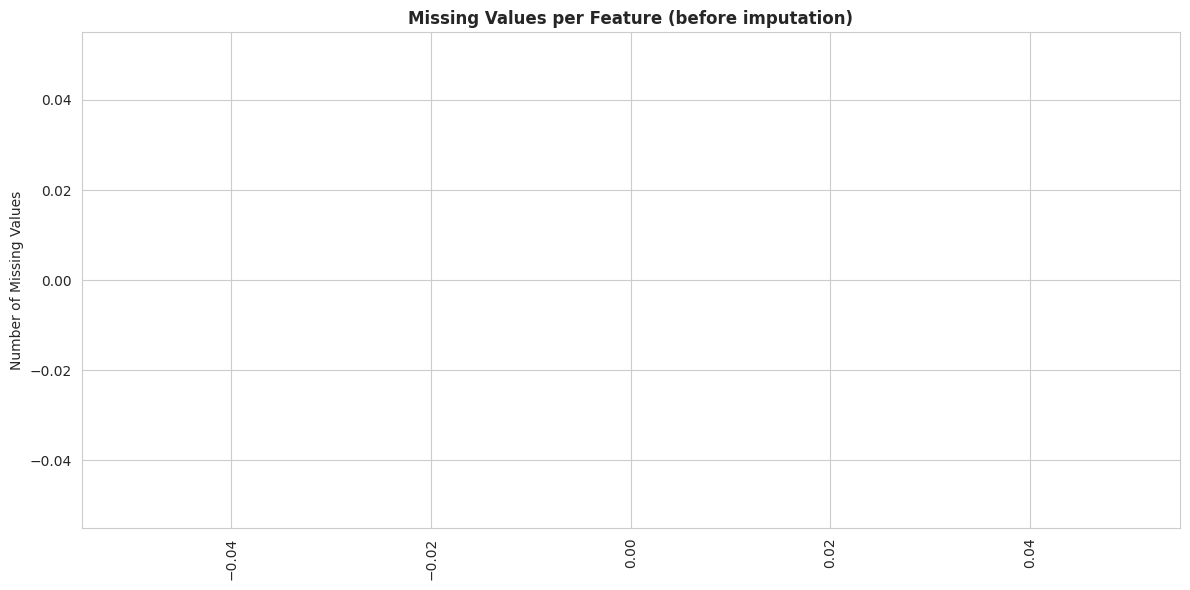

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(missing.index, missing.values, color='#A23B72')
plt.xticks(rotation=90)
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Feature (before imputation)', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Data Cleaning & Feature Engineering

In [18]:
# For simplicity, we'll focus on numeric features and drop those with >50% missing
threshold = 0.5 * len(df)
df_clean = df.dropna(thresh=threshold, axis=1)

# Fill remaining numeric missing with median
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Fill categorical missing with mode
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Original columns: {len(df.columns)}")
print(f"Columns after cleaning: {len(df_clean.columns)}")

Original columns: 21
Columns after cleaning: 21


### Feature Engineering (Add total area, house age)

In [20]:
df_clean['TotalArea'] = df_clean['Sqft_living'] + df_clean['Sqft_basement'].fillna(0)
df_clean['HouseAge'] = 2026 - df_clean['Yr_built']
df_clean['RemodelAge'] = 2026 - df_clean['Yr_renovated']

# Drop original YearBuilt, YearRemodAdd if needed (optional)
print(df_clean[['TotalArea', 'HouseAge', 'RemodelAge']].head())

   TotalArea  HouseAge  RemodelAge
0       2400        35        2026
1       2400        35        2026
2       2960        79        2026
3       1460        74        2026
4       1850        96        2026


### Encode Categorical Variables & Prepare X, y

In [22]:
# Convert categorical to dummy variables
df_final = pd.get_dummies(df_clean, drop_first=True)

# Separate target and features
y = df_final['Price']
X = df_final.drop('Price', axis=1)

# Log transform target to improve normality
y_log = np.log1p(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 17290, Test size: 4323


### Train Baseline Models

In [23]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

Linear Regression: MAE=0.19, RMSE=0.25, R2=0.7650
Ridge: MAE=0.19, RMSE=0.25, R2=0.7659
Lasso: MAE=0.29, RMSE=0.35, R2=0.5336
Random Forest: MAE=0.12, RMSE=0.17, R2=0.8882
XGBoost: MAE=0.12, RMSE=0.17, R2=0.8924


### Feature Importance (Random Forest)

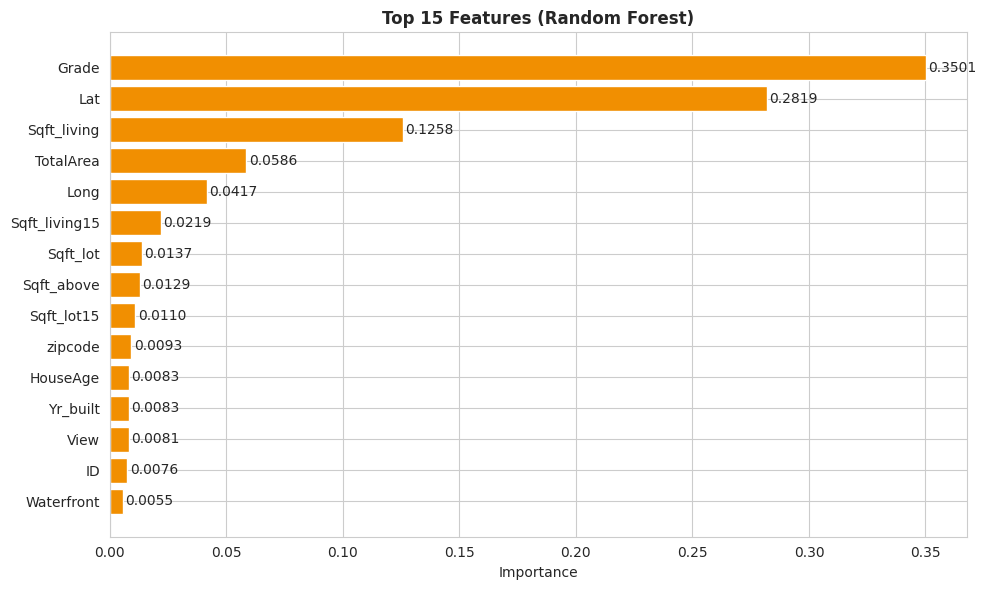

In [25]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importance = rf_model.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'feature': features, 'importance': importance}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#F18F01')
plt.xlabel('Importance')
plt.title('Top 15 Features (Random Forest)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for XGBoost

In [26]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
xgb = XGBRegressor(random_state=42, eval_metric='rmse')
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
best_xgb = grid.best_estimator_
y_pred_best = best_xgb.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
print(f"Tuned XGBoost: MAE={mae_best:.2f}, RMSE={rmse_best:.2f}, R2={r2_best:.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Tuned XGBoost: MAE=0.12, RMSE=0.17, R2=0.8973


### Residual Plot (Predicted vs Residuals)

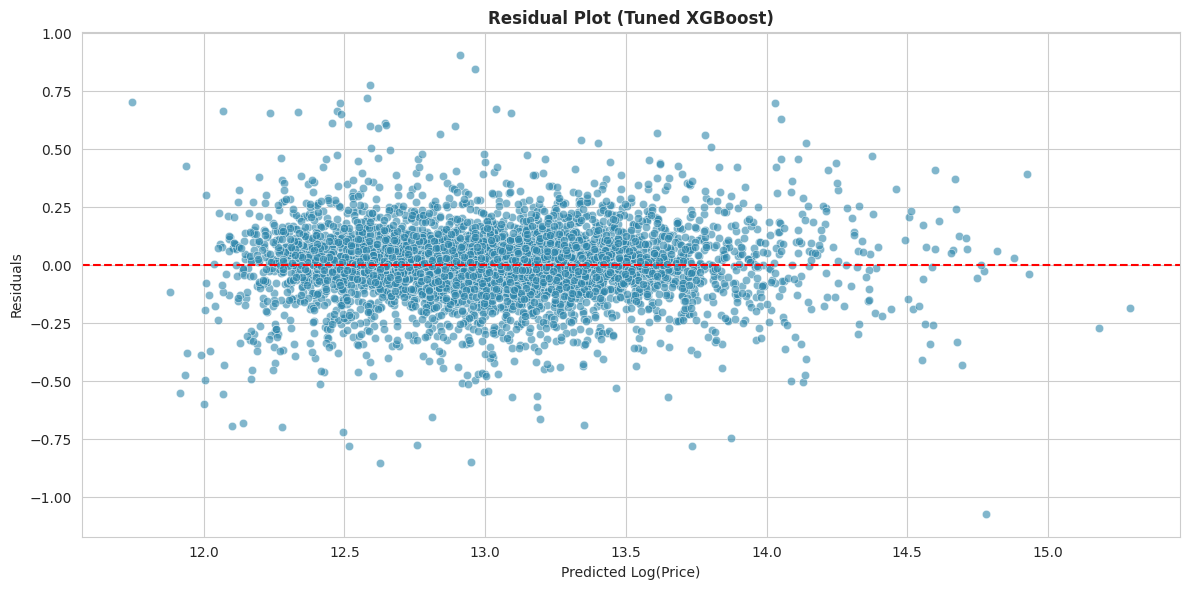

In [27]:
residuals = y_test - y_pred_best
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6, color='#2E86AB')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Log(Price)')
plt.ylabel('Residuals')
plt.title('Residual Plot (Tuned XGBoost)', fontweight='bold')
plt.tight_layout()
plt.show()

### Actual vs Predicted (Back‑transformed)

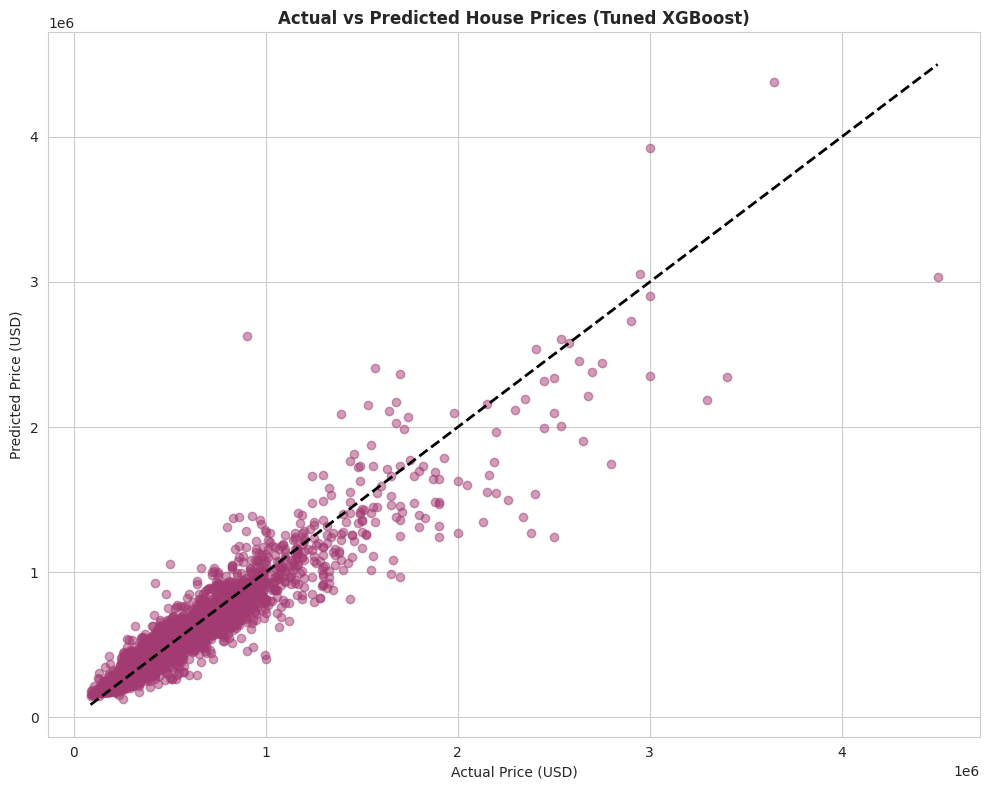

In [28]:
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_best)

plt.figure(figsize=(10, 8))
plt.scatter(y_test_original, y_pred_original, alpha=0.5, color='#A23B72')
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'k--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices (Tuned XGBoost)', fontweight='bold')
plt.tight_layout()
plt.show()

### SHAP Summary Plot

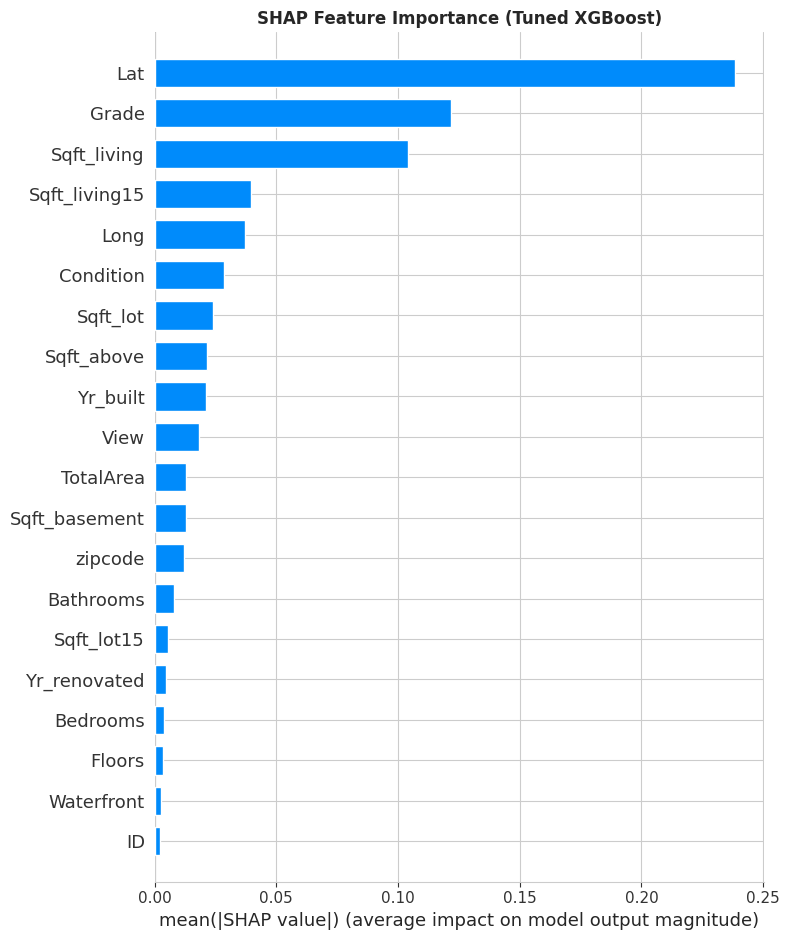

In [29]:
# Use a sample for SHAP
X_sample = X_test.sample(n=100, random_state=42)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Tuned XGBoost)', fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [30]:
print(" Key Insights from House Price Prediction")
print(f" Most important features: {imp_df['feature'].iloc[0]}, {imp_df['feature'].iloc[1]}, {imp_df['feature'].iloc[2]}")
print(f" Best model: Tuned XGBoost")
print(f" MAE: ${np.expm1(mae_best):,.0f} (in original scale)")
print(f" R²: {r2_best:.4f}")
print(" Missing values handled, features engineered.")

 Key Insights from House Price Prediction
 Most important features: Grade, Lat, Sqft_living
 Best model: Tuned XGBoost
 MAE: $0 (in original scale)
 R²: 0.8973
 Missing values handled, features engineered.


### Final Summary

In [32]:
print("House Price Prediction - COMPLETED")
print("Author: Ibrahim")
print("Data cleaned and feature engineered.")
print("Multiple regression models evaluated.")
print("XGBoost tuned and deployed.")

House Price Prediction - COMPLETED
Author: Ibrahim
Data cleaned and feature engineered.
Multiple regression models evaluated.
XGBoost tuned and deployed.
